# 03MIAR - Algoritmos de Optimización
## Actividad Guiada 1

**Nombre:** Donald Silva

**URL:** `https://github.com/dsilvas2001/03MIAR_DonaldSilva_AG1-.git`

---

### Objetivos de la actividad

- Comprender la utilidad y aplicar algoritmos de **divide y vencerás**.
- Comprender la utilidad y aplicar algoritmos **voraces** (*greedy*).
- Comprender la utilidad y aplicar algoritmos de **vuelta atrás** (*backtracking*).
- Comprender la utilidad y aplicar **programación dinámica**.
- Ejercicio avanzado: **búsqueda de los dos puntos más cercanos** en 1D, 2D y 3D.

### Contenido

| Apartado | Técnica | Problema |
|---|---|---|
| 1 | Divide y vencerás | Torres de Hanói · Sucesión de Fibonacci |
| 2 | Voraz | Devolución de cambio |
| 3 | Vuelta atrás | N reinas |
| 4 | Programación dinámica | Viaje por el río |
| 5 | Divide y vencerás (avanzado) | Los dos puntos más cercanos en 1D, 2D y 3D |

### Cómo se verifica este notebook

No se incluyen salidas precalculadas: está pensado para ejecutarse de arriba abajo
(*Entorno de ejecución → Ejecutar todo*). Cada apartado termina con `assert` contra valores de
referencia conocidos como número de movimientos de Hanói, número de soluciones de las N reinas, coste
mínimo del viaje por el río, fuerza bruta frente a divide y vencerás, de modo que **si el notebook
se ejecuta entero sin lanzar ninguna excepción, los algoritmos son correctos**.

Solo se usan la biblioteca estándar y `matplotlib`, ambas disponibles en Colab sin instalar nada.

In [14]:
# Utilidades comunes a todo el notebook
import math
import random
import sys
import time
from functools import lru_cache

random.seed(42)               # Semilla fija: todos los experimentos son reproducibles
sys.setrecursionlimit(10000)  # Varios algoritmos son recursivos sobre listas grandes


def cronometra(funcion, *args, **kwargs):
    """Ejecuta funcion(*args, **kwargs) y devuelve (resultado, segundos_empleados)."""
    inicio = time.perf_counter()
    resultado = funcion(*args, **kwargs)
    return resultado, time.perf_counter() - inicio


print("Python", sys.version.split()[0])

Python 3.14.5


---
# 1. Divide y vencerás

La técnica consta de tres pasos:

1. **Dividir** el problema en subproblemas del mismo tipo pero de menor tamaño.
2. **Vencer**: resolver cada subproblema recursivamente, hasta llegar a un caso base lo bastante
   pequeño como para resolverlo de forma directa.
3. **Combinar** las soluciones parciales en la solución del problema original.

El coste se expresa con una recurrencia $T(n) = a \cdot T(n/b) + f(n)$, donde $a$ es el número de
subproblemas, $n/b$ su tamaño y $f(n)$ el coste de dividir y combinar.

## 1.1 Torres de Hanói

Hay que trasladar $n$ discos de una varilla a otra sin colocar nunca un disco grande sobre uno más
pequeño. La descomposición recursiva es directa:

$$H(n) = \underbrace{H(n-1)}_{\text{aparto los } n-1 \text{ discos de encima}} + \underbrace{1}_{\text{muevo el mayor}} + \underbrace{H(n-1)}_{\text{los devuelvo sobre él}}$$

**El truco `6 - desde - hasta`.** Las varillas se numeran 1, 2 y 3, y $1 + 2 + 3 = 6$. Por tanto la
varilla auxiliar la que no es ni origen ni destino se obtiene siempre restando a 6 las otras dos.
Es una forma compacta de evitar un `if` con tres casos.

In [15]:
def torres_hanoi(n, desde=1, hasta=3):
    # Imprime la secuencia de movimientos para llevar n discos de desde a hasta.
    if n == 1:
        # Caso base: un único disco se mueve directamente, no hay nada encima de él.
        print(f"Mueve el disco 1 de la varilla {desde} a la varilla {hasta}")
    else:
        auxiliar = 6 - desde - hasta          # La varilla que no es ni origen ni destino
        torres_hanoi(n - 1, desde, auxiliar)  # 1) Aparto los n-1 discos superiores
        print(f"Mueve el disco {n} de la varilla {desde} a la varilla {hasta}")  # 2) Muevo el mayor
        torres_hanoi(n - 1, auxiliar, hasta)  # 3) Devuelvo los n-1 discos sobre él


print("Solución para 3 discos (de la varilla 1 a la varilla 3):\n")
torres_hanoi(3, 1, 3)

Solución para 3 discos (de la varilla 1 a la varilla 3):

Mueve el disco 1 de la varilla 1 a la varilla 3
Mueve el disco 2 de la varilla 1 a la varilla 2
Mueve el disco 1 de la varilla 3 a la varilla 2
Mueve el disco 3 de la varilla 1 a la varilla 3
Mueve el disco 1 de la varilla 2 a la varilla 1
Mueve el disco 2 de la varilla 2 a la varilla 3
Mueve el disco 1 de la varilla 1 a la varilla 3


In [16]:
def torres_hanoi_movimientos(n, desde=1, hasta=3, movimientos=None):
    """
    Igual que torres_hanoi, pero acumula los movimientos en vez de imprimirlos.
    Cada movimiento es una tupla (disco, varilla_origen, varilla_destino). Devolver la
    secuencia en lugar de imprimirla permite contarla y, sobre todo, validarla.
    """
    if movimientos is None:
        movimientos = []

    if n == 1:
        movimientos.append((1, desde, hasta))
    else:
        auxiliar = 6 - desde - hasta
        torres_hanoi_movimientos(n - 1, desde, auxiliar, movimientos)
        movimientos.append((n, desde, hasta))
        torres_hanoi_movimientos(n - 1, auxiliar, hasta, movimientos)

    return movimientos


def simula(n, movimientos, desde=1, hasta=3):
    """Ejecuta la secuencia sobre tres pilas reales y comprueba que es legal y completa.

    Cada varilla es una lista en la que el último elemento es el disco de encima.
    La varilla de partida arranca con los discos n, n-1, ..., 1 (el mayor abajo).
    """
    varillas = {1: [], 2: [], 3: []}
    varillas[desde] = list(range(n, 0, -1))

    for disco, origen, destino in movimientos:
        assert varillas[origen], f"Se intenta mover desde la varilla vacía {origen}"
        movido = varillas[origen].pop()
        assert movido == disco, f"Se esperaba mover el disco {disco}, pero arriba estaba el {movido}"
        assert not varillas[destino] or varillas[destino][-1] > disco, \
            f"El disco {disco} no puede apoyarse sobre el disco {varillas[destino][-1]}"
        varillas[destino].append(movido)

    # La solución es correcta si todos los discos acaban ordenados en la varilla destino
    return varillas[hasta] == list(range(n, 0, -1))


# Verificación: el número de movimientos debe ser exactamente 2^n - 1 y la secuencia, legal
for n in range(1, 15):
    movs = torres_hanoi_movimientos(n)
    assert len(movs) == 2 ** n - 1, f"n={n}: {len(movs)} movimientos, se esperaban {2 ** n - 1}"
    assert simula(n, movs), f"n={n}: la secuencia de movimientos no es válida"

print("Verificado: para n = 1..14 la secuencia es legal y tiene exactamente 2^n - 1 movimientos.")

Verificado: para n = 1..14 la secuencia es legal y tiene exactamente 2^n - 1 movimientos.


In [17]:
# Crecimiento exponencial: cada disco añadido duplica el trabajo
print(f"{'n':>3} | {'movimientos':>12} | {'2^n - 1':>12} | {'segundos':>10} | {'t(n)/t(n-1)':>12}")
print("-" * 64)

anterior = None
for n in range(10, 21):
    movs, segundos = cronometra(torres_hanoi_movimientos, n)
    ratio = "-" if not anterior else f"{segundos / anterior:.2f}"
    print(f"{n:>3} | {len(movs):>12,} | {2 ** n - 1:>12,} | {segundos:>10.4f} | {ratio:>12}")
    anterior = segundos

  n |  movimientos |      2^n - 1 |   segundos |  t(n)/t(n-1)
----------------------------------------------------------------
 10 |        1,023 |        1,023 |     0.0002 |            -
 11 |        2,047 |        2,047 |     0.0004 |         1.68
 12 |        4,095 |        4,095 |     0.0009 |         2.36
 13 |        8,191 |        8,191 |     0.0016 |         1.74
 14 |       16,383 |       16,383 |     0.0040 |         2.42
 15 |       32,767 |       32,767 |     0.0072 |         1.80
 16 |       65,535 |       65,535 |     0.0165 |         2.30
 17 |      131,071 |      131,071 |     0.0356 |         2.16
 18 |      262,143 |      262,143 |     0.0618 |         1.74
 19 |      524,287 |      524,287 |     0.1681 |         2.72
 20 |    1,048,575 |    1,048,575 |     0.2700 |         1.61


### Complejidad de las Torres de Hanói

La recurrencia $T(n) = 2\,T(n-1) + 1$ con $T(1) = 1$ se resuelve por expansión:

$$T(n) = 2^n - 1 \in O(2^n)$$

El coste es **exponencial y además óptimo**: no existe ninguna solución con menos movimientos,
porque para poder mover el disco mayor hay que haber apartado antes los $n-1$ discos superiores.
La columna $t(n)/t(n-1)$ de la tabla tiende a **2**, exactamente lo que predice la fórmula.

Es un caso peculiar de divide y vencerás: dividir **no** abarata el problema, porque los
subproblemas no son de tamaño $n/b$ sino $n-1$, y además hay dos de ellos. Aquí la recursión sirve
para *expresar* la solución con claridad, no para acelerarla.

## 1.2 Sucesión de Fibonacci

$$F(n) = F(n-1) + F(n-2), \qquad F(0) = 0,\quad F(1) = 1$$

> **Nota sobre la versión vista en clase.** El código original usa `if N < 2: return 1`, lo que
> desplaza la sucesión una posición: devuelve $F(n+1)$ en la numeración estándar. Por eso
> `Fibonacci(5)` imprime **8**, que es $F(6)$, y no $F(5) = 5$. Abajo se comprueba esa relación con
> un `assert` y se implementa además la versión con la numeración habitual.

In [18]:
def fibonacci_original(n):
    # Versión tal cual se vio en clase: el caso base return 1 desplaza la sucesión.
    if n < 2:
        return 1
    return fibonacci_original(n - 1) + fibonacci_original(n - 2)


def fibonacci_recursivo(n):
    """Definición estándar F(0)=0, F(1)=1.

    Divide y vencerás puro, pero con coste O(phi^n): los subproblemas se solapan y se
    recalculan una y otra vez.
    """
    if n < 2:
        return n
    return fibonacci_recursivo(n - 1) + fibonacci_recursivo(n - 2)


@lru_cache(maxsize=None)
def fibonacci_memoizado(n):
    # Mismo árbol de recursión, pero cada subproblema se resuelve una sola vez: O(n).
    if n < 2:
        return n
    return fibonacci_memoizado(n - 1) + fibonacci_memoizado(n - 2)


def fibonacci_iterativo(n):
    # Recorrido ascendente: O(n) en tiempo y O(1) en memoria.
    if n < 2:
        return n
    anterior, actual = 0, 1
    for _ in range(2, n + 1):
        anterior, actual = actual, anterior + actual
    return actual


referencia = [fibonacci_iterativo(n) for n in range(21)]
print("F(0..20) =", referencia)

# Las tres implementaciones deben coincidir
assert [fibonacci_recursivo(n) for n in range(21)] == referencia
assert [fibonacci_memoizado(n) for n in range(21)] == referencia

# Y la del enunciado devuelve siempre el término siguiente
assert all(fibonacci_original(n) == fibonacci_iterativo(n + 1) for n in range(20))

print("\nVerificado: las tres versiones coinciden y fibonacci_original(n) == F(n+1)")
print(f"fibonacci_original(5) = {fibonacci_original(5)}  <-- es F(6); F(5) = {fibonacci_iterativo(5)}")

F(0..20) = [0, 1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144, 233, 377, 610, 987, 1597, 2584, 4181, 6765]

Verificado: las tres versiones coinciden y fibonacci_original(n) == F(n+1)
fibonacci_original(5) = 8  <-- es F(6); F(5) = 5


In [13]:
# El precio de recalcular los subproblemas solapados
print(f"{'n':>3} | {'recursivo (s)':>14} | {'memoizado (s)':>14} | {'iterativo (s)':>14} | {'veces más lento':>16}")
print("-" * 82)

for n in (20, 25, 28, 30):
    _, t_rec = cronometra(fibonacci_recursivo, n)

    fibonacci_memoizado.cache_clear()   # Sin esto mediríamos la caché, no el algoritmo
    _, t_mem = cronometra(fibonacci_memoizado, n)

    _, t_ite = cronometra(fibonacci_iterativo, n)

    factor = t_rec / t_ite if t_ite > 0 else float("inf")
    print(f"{n:>3} | {t_rec:>14.6f} | {t_mem:>14.6f} | {t_ite:>14.6f} | {factor:>16,.0f}")

  n |  recursivo (s) |  memoizado (s) |  iterativo (s) |  veces más lento
----------------------------------------------------------------------------------
 20 |       0.002273 |       0.000022 |       0.000005 |              474
 25 |       0.023923 |       0.000045 |       0.000008 |            2,814
 28 |       0.142191 |       0.000049 |       0.000011 |           13,414
 30 |       0.323485 |       0.000034 |       0.000008 |           41,472


### Complejidad de Fibonacci

| Versión | Tiempo | Memoria | Motivo |
|---|---|---|---|
| Recursiva ingenua | $O(\varphi^n)$, con $\varphi \approx 1{,}618$ | $O(n)$ (pila) | Recalcula los mismos subproblemas |
| Memoizada | $O(n)$ | $O(n)$ | Cada subproblema se resuelve una vez |
| Iterativa | $O(n)$ | $O(1)$ | Solo guarda los dos últimos términos |

**Conclusión importante:** divide y vencerás solo compensa cuando los subproblemas son
*independientes*. En Fibonacci **se solapan**, y por eso el árbol de recursión repite trabajo de
forma exponencial. Cuando los subproblemas se solapan, la técnica adecuada no es divide y vencerás
sino **programación dinámica** memoización o tabla ascendente, que es justo lo que se aplica en
el apartado 4.

---
# 2. Técnica voraz: devolución de cambio

Un algoritmo **voraz** construye la solución en etapas y en cada una toma la decisión que parece
mejor *en ese momento*, sin reconsiderarla nunca. Es rápido y sencillo, pero **no garantiza el
óptimo**: solo lo alcanza si el problema tiene la propiedad de la elección voraz.

En la devolución de cambio la decisión local es «entrega tantas monedas como puedas de la de mayor
valor que todavía quepa».

> **Dos fallos de la versión vista en clase.**
>
> 1. El `return SOLUCION` está **dentro** del bucle y condicionado a `ValorAcumulado == N`. Si el
>    recorrido termina sin cuadrar exactamente, la función devuelve `None` de forma implícita en
>    lugar de informar de que no ha podido dar el cambio.
> 2. Se da por hecho que el sistema monetario llega ya ordenado de mayor a menor. Si no lo está, el
>    algoritmo deja de ser voraz: sigue devolviendo monedas que suman el importe exacto, pero puede
>    usar muchísimas más de las necesarias. Con `[1, 5, 10, 25]` y un cambio de 15 devuelve
>    `[15, 0, 0, 0]`, quince monedas de 1 donde bastaban dos.
>
> La versión de abajo ordena el sistema, devuelve **siempre** un resultado y señala explícitamente
> cuánto ha quedado sin devolver.

In [19]:
def cambio_monedas(cantidad, sistema):
    """Devolución de cambio por técnica voraz.

    En cada etapa se toma la mayor cantidad posible de la moneda más grande que aún quepa
    (óptimo local), confiando en que eso conduzca al óptimo global.

    Devuelve (solucion, restante):
      - solucion: diccionario {valor_de_la_moneda: número_de_monedas}, solo con las usadas.
      - restante: lo que ha quedado sin devolver. Si no es 0, el voraz ha fracasado.
    """
    monedas = sorted(sistema, reverse=True)   # El voraz exige recorrer de mayor a menor
    solucion = {}
    restante = cantidad

    for valor in monedas:
        if valor <= restante:
            cuantas = restante // valor       # Cuántas monedas de este valor caben
            solucion[valor] = cuantas
            restante -= cuantas * valor       # Lo que sigue pendiente de devolver
        if restante == 0:
            break

    return solucion, restante


def cambio_monedas_dp(cantidad, sistema):
    """Devolución de cambio ÓPTIMA por programación dinámica.

    minimo[c] = número mínimo de monedas para devolver exactamente el importe c.
    Se rellena de forma ascendente: minimo[c] = 1 + min(minimo[c - valor]) para cada moneda.

    Complejidad O(cantidad * len(sistema)) en tiempo y O(cantidad) en memoria.
    """
    INFINITO = float("inf")
    minimo = [0] + [INFINITO] * cantidad
    ultima = [None] * (cantidad + 1)          # Moneda con la que se alcanza cada importe

    for c in range(1, cantidad + 1):
        for valor in sistema:
            if valor <= c and minimo[c - valor] + 1 < minimo[c]:
                minimo[c] = minimo[c - valor] + 1
                ultima[c] = valor

    if minimo[cantidad] == INFINITO:
        return None, cantidad                 # El importe no es representable

    # Reconstrucción de la solución deshaciendo el camino de decisiones
    solucion = {}
    c = cantidad
    while c > 0:
        valor = ultima[c]
        solucion[valor] = solucion.get(valor, 0) + 1
        c -= valor

    return dict(sorted(solucion.items(), reverse=True)), 0


def formatea(solucion):
    """Convierte {25: 1, 1: 2} en la cadena '1x25 + 2x1'."""
    if not solucion:
        return "-"
    return " + ".join(f"{cuantas}x{valor}" for valor, cuantas in solucion.items())

In [23]:
CASOS = [
    ("Canónico (céntimos de euro)", [200, 100, 50, 20, 10, 5, 2, 1], 288),
    ("Canónico (centavos USD)",     [25, 10, 5, 1],                   27),
    ("Canónico (centavos USD)",     [25, 10, 5, 1],                   15),
    ("NO canónico",                 [11, 5, 1],                       15),
    ("NO canónico",                 [4, 3, 1],                         6),
    ("NO canónico, sin moneda 1",   [5, 3],                            6),
]

for descripcion, sistema, cantidad in CASOS:
    voraz, restante = cambio_monedas(cantidad, sistema)
    optima, _ = cambio_monedas_dp(cantidad, sistema)

    monedas_voraz = sum(voraz.values()) if restante == 0 else None
    monedas_optima = sum(optima.values()) if optima else None

    print(f"{descripcion}  ->  sistema {sistema}, cambio de {cantidad}")
    if restante == 0:
        print(f"   voraz : {formatea(voraz):<46} {monedas_voraz} monedas")
    else:
        print(f"   voraz : FRACASA, quedan {restante} sin devolver ({formatea(voraz)})")
    if optima is None:
        print("   óptimo: el importe no se puede formar con ese sistema")
    else:
        print(f"   óptimo: {formatea(optima):<46} {monedas_optima} monedas")

    if monedas_voraz is not None and monedas_optima is not None and monedas_voraz > monedas_optima:
        print(f"   >>> el voraz usa {monedas_voraz - monedas_optima} moneda(s) de más")
    print()

Canónico (céntimos de euro)  ->  sistema [200, 100, 50, 20, 10, 5, 2, 1], cambio de 288
   voraz : 1x200 + 1x50 + 1x20 + 1x10 + 1x5 + 1x2 + 1x1   7 monedas
   óptimo: 1x200 + 1x50 + 1x20 + 1x10 + 1x5 + 1x2 + 1x1   7 monedas

Canónico (centavos USD)  ->  sistema [25, 10, 5, 1], cambio de 27
   voraz : 1x25 + 2x1                                     3 monedas
   óptimo: 1x25 + 2x1                                     3 monedas

Canónico (centavos USD)  ->  sistema [25, 10, 5, 1], cambio de 15
   voraz : 1x10 + 1x5                                     2 monedas
   óptimo: 1x10 + 1x5                                     2 monedas

NO canónico  ->  sistema [11, 5, 1], cambio de 15
   voraz : 1x11 + 4x1                                     5 monedas
   óptimo: 3x5                                            3 monedas
   >>> el voraz usa 2 moneda(s) de más

NO canónico  ->  sistema [4, 3, 1], cambio de 6
   voraz : 1x4 + 2x1                                      3 monedas
   óptimo: 2x3             

In [24]:
# --- Verificación -----------------------------------------------------------------------------

# Casos concretos en los que el voraz falla, y de dos maneras distintas
assert cambio_monedas(15, [11, 5, 1])[0] == {11: 1, 1: 4}        # 5 monedas...
assert sum(cambio_monedas_dp(15, [11, 5, 1])[0].values()) == 3   # ...cuando bastan 3 (5+5+5)
assert cambio_monedas(6, [5, 3])[1] != 0                         # aquí ni siquiera da el cambio
assert cambio_monedas_dp(6, [5, 3])[0] == {3: 2}                 # aunque sí es posible: 3+3


@lru_cache(maxsize=None)
def minimo_monedas_recursivo(cantidad, sistema):
    # Control independiente: mínimo de monedas por recursión con memoización (top-down).
    if cantidad == 0:
        return 0
    mejor = float("inf")
    for valor in sistema:
        if valor <= cantidad:
            mejor = min(mejor, minimo_monedas_recursivo(cantidad - valor, sistema) + 1)
    return mejor


""" La versión ascendente (bottom-up) debe coincidir con la descendente (top-down)
 para todos los importes hasta 80 en cuatro sistemas monetarios distintos"""
for sistema in ([25, 10, 5, 1], [11, 5, 1], [4, 3, 1], [5, 3]):
    for cantidad in range(1, 81):
        esperado = minimo_monedas_recursivo(cantidad, tuple(sistema))
        solucion, restante = cambio_monedas_dp(cantidad, sistema)

        if esperado == float("inf"):
            assert solucion is None, f"{sistema} / {cantidad}: no debería haber solución"
        else:
            assert restante == 0
            assert sum(solucion.values()) == esperado, f"{sistema} / {cantidad}: no es óptima"
            # Y las monedas devueltas deben sumar exactamente el importe pedido
            assert sum(v * c for v, c in solucion.items()) == cantidad

        # El voraz nunca puede ser mejor que el óptimo
        voraz, sobra = cambio_monedas(cantidad, sistema)
        if sobra == 0 and esperado != float("inf"):
            assert sum(voraz.values()) >= esperado

print("Verificado: la solución por programación dinámica es óptima en 320 casos,")
print("y el voraz nunca la mejora (pero sí la empeora, y a veces fracasa por completo).")

Verificado: la solución por programación dinámica es óptima en 320 casos,
y el voraz nunca la mejora (pero sí la empeora, y a veces fracasa por completo).


### Complejidad y cuándo se puede confiar en el voraz

| Algoritmo | Tiempo | Memoria | ¿Óptimo? |
|---|---|---|---|
| Voraz | $O(m \log m)$ por la ordenación, $m$ = número de monedas | $O(m)$ | Solo en sistemas **canónicos** |
| Programación dinámica | $O(n \cdot m)$, $n$ = importe | $O(n)$ | **Siempre** |

Un sistema monetario es *canónico* cuando el voraz siempre da el óptimo. Los sistemas reales
(euro, dólar) lo son, y de ahí que la intuición de «dar primero las monedas grandes» funcione en la
práctica. Pero basta un sistema artificial para romperlo:

- Con `[11, 5, 1]` y 15: el voraz coge el 11 y se queda con 4 monedas de 1 → **5 monedas**, cuando
  con tres monedas de 5 bastaría → **3 monedas**.
- Con `[5, 3]` y 6: el voraz coge el 5 y se queda atascado con un resto de 1 → **no encuentra
  solución**, pese a que 3 + 3 sí la da. Este segundo caso es el más grave: el voraz no solo pierde
  optimalidad, es que puede llegar a un callejón sin salida y no ser capaz de resolver el problema.

---
# 3. Vuelta atrás (*backtracking*): las N reinas

Hay que colocar $N$ reinas en un tablero de $N \times N$ sin que ninguna ataque a otra. El esquema
de vuelta atrás es:

1. El problema se divide en **etapas**; en cada una se toma una decisión parcial.
2. Se comprueba si la solución parcial sigue siendo **prometedora**.
3. Si lo es, se profundiza a la etapa siguiente.
4. Si no, se **poda** esa rama y se prueba la siguiente alternativa.
5. Si se agotan todas las alternativas de una etapa, se **retrocede** a la anterior.

**Representación.** `solucion[c]` es la fila (de 1 a $N$) que ocupa la reina de la columna `c`. Al
guardar una única reina por columna, los conflictos por columna quedan descartados por
construcción, y solo hay que vigilar filas y diagonales:

- **Misma fila** → el mismo valor aparece repetido en la lista.
- **Misma diagonal** → la distancia horizontal iguala a la vertical:
  $|c_1 - c_2| = |\text{solucion}[c_1] - \text{solucion}[c_2]|$.

In [25]:
def es_prometedora(solucion, etapa):
    """¿Sigue siendo válida la solución parcial hasta `etapa` (incluida)?

    Nota sobre la versión de clase: allí se hacía `solucion.count(solucion[i])` sobre la lista
    COMPLETA. Funciona solo porque las posiciones aún sin decidir valen 0 y las filas se numeran
    desde 1, así que los ceros nunca colisionan. Es un invariante frágil; aquí se recorta la lista
    al prefijo ya decidido, que es lo que realmente se quiere comprobar.
    """
    parcial = solucion[:etapa + 1]

    for i in range(len(parcial)):
        if parcial.count(parcial[i]) > 1:                 # Dos reinas en la misma fila
            return False
        for j in range(i + 1, len(parcial)):
            if abs(i - j) == abs(parcial[i] - parcial[j]):  # Dos reinas en la misma diagonal
                return False

    return True


def reinas(N, solucion=None, etapa=0, soluciones=None):
    """Vuelta atrás clásico: una reina por columna, retrocediendo al primer conflicto.

    Los valores por defecto son `None` y no `[]`. Una lista como valor por defecto se crea UNA
    sola vez, al definir la función, y se comparte entre todas las llamadas: la segunda invocación
    arrastraría los datos de la primera.
    """
    if solucion is None:
        solucion = [0] * N
    if soluciones is None:
        soluciones = []

    for fila in range(1, N + 1):
        solucion[etapa] = fila                            # Decisión de esta etapa

        if es_prometedora(solucion, etapa):
            if etapa == N - 1:
                soluciones.append(list(solucion))         # Copia: `solucion` seguirá cambiando
            else:
                reinas(N, solucion, etapa + 1, soluciones)

        solucion[etapa] = 0                               # Vuelta atrás: se deshace la decisión

    return soluciones


def es_solucion_valida(solucion):
    # Comprobación desde cero, sin reutilizar `es_prometedora`: ninguna pareja se ataca.
    n = len(solucion)
    if sorted(solucion) != sorted(range(1, n + 1)):
        return False
    for i in range(n):
        for j in range(i + 1, n):
            if abs(i - j) == abs(solucion[i] - solucion[j]):
                return False
    return True


def dibuja_tablero(solucion):
    # Dibuja el tablero. `solucion[c]` es la fila de la reina de la columna c.
    n = len(solucion)
    for fila in range(1, n + 1):
        print("   " + " ".join("♛" if solucion[columna] == fila else "·" for columna in range(n)))


soluciones_4 = reinas(4)
print(f"El problema de las 4 reinas tiene {len(soluciones_4)} soluciones: {soluciones_4}\n")
for solucion in soluciones_4:
    dibuja_tablero(solucion)
    print()

El problema de las 4 reinas tiene 2 soluciones: [[2, 4, 1, 3], [3, 1, 4, 2]]

   · · ♛ ·
   ♛ · · ·
   · · · ♛
   · ♛ · ·

   · ♛ · ·
   · · · ♛
   ♛ · · ·
   · · ♛ ·



In [26]:
def reinas_rapido(N):
    """Misma búsqueda, pero la comprobación de conflictos pasa de O(etapa^2) a O(1).

    En vez de recorrer las reinas ya colocadas, se mantienen tres conjuntos:
      - `filas`        : filas ya ocupadas.
      - `diagonales_1` : diagonales descendentes, constantes en (columna - fila).
      - `diagonales_2` : diagonales ascendentes, constantes en (columna + fila).

    Una casilla es válida si su fila y sus dos diagonales están libres. Al retroceder se
    deshacen las tres inserciones, que es la esencia de la vuelta atrás.
    """
    soluciones = []
    solucion = [0] * N
    filas, diagonales_1, diagonales_2 = set(), set(), set()

    def coloca(columna):
        if columna == N:
            soluciones.append(list(solucion))
            return

        for fila in range(1, N + 1):
            if fila in filas or (columna - fila) in diagonales_1 or (columna + fila) in diagonales_2:
                continue

            solucion[columna] = fila
            filas.add(fila)
            diagonales_1.add(columna - fila)
            diagonales_2.add(columna + fila)

            coloca(columna + 1)

            filas.discard(fila)                # Vuelta atrás
            diagonales_1.discard(columna - fila)
            diagonales_2.discard(columna + fila)
            solucion[columna] = 0

    coloca(0)
    return soluciones


# Número de soluciones conocido del problema (sucesión A000170 de la OEIS)
SOLUCIONES_CONOCIDAS = {1: 1, 2: 0, 3: 0, 4: 2, 5: 10, 6: 4, 7: 40, 8: 92, 9: 352, 10: 724, 11: 2680}

print(f"{'N':>3} | {'soluciones':>11} | {'reinas (s)':>11} | {'reinas_rapido (s)':>18} | {'mejora':>8}")
print("-" * 66)

for N in range(1, 10):
    lentas, t_lento = cronometra(reinas, N)
    rapidas, t_rapido = cronometra(reinas_rapido, N)

    # Las dos implementaciones deben encontrar EXACTAMENTE el mismo conjunto de soluciones
    assert sorted(lentas) == sorted(rapidas), f"N={N}: las dos versiones discrepan"
    assert len(lentas) == SOLUCIONES_CONOCIDAS[N], f"N={N}: {len(lentas)} != {SOLUCIONES_CONOCIDAS[N]}"
    assert all(es_solucion_valida(s) for s in lentas), f"N={N}: hay soluciones inválidas"

    mejora = f"{t_lento / t_rapido:.1f}x" if t_rapido > 0 else "-"
    print(f"{N:>3} | {len(lentas):>11,} | {t_lento:>11.4f} | {t_rapido:>18.4f} | {mejora:>8}")

# Los tamaños grandes solo con la versión rápida
for N in (10, 11):
    soluciones, segundos = cronometra(reinas_rapido, N)
    assert len(soluciones) == SOLUCIONES_CONOCIDAS[N]
    assert all(es_solucion_valida(s) for s in soluciones)
    print(f"{N:>3} | {len(soluciones):>11,} | {'-':>11} | {segundos:>18.4f} | {'-':>8}")

print("\nVerificado: ambas implementaciones coinciden entre sí y con los valores conocidos.")

  N |  soluciones |  reinas (s) |  reinas_rapido (s) |   mejora
------------------------------------------------------------------
  1 |           1 |      0.0000 |             0.0001 |     0.2x
  2 |           0 |      0.0000 |             0.0000 |     1.2x
  3 |           0 |      0.0000 |             0.0000 |     2.3x
  4 |           2 |      0.0002 |             0.0000 |     3.4x
  5 |          10 |      0.0004 |             0.0001 |     4.5x
  6 |           4 |      0.0024 |             0.0003 |     8.8x
  7 |          40 |      0.0099 |             0.0014 |     7.3x
  8 |          92 |      0.0606 |             0.0040 |    15.0x
  9 |         352 |      0.3031 |             0.0217 |    13.9x
 10 |         724 |           - |             0.0807 |        -
 11 |       2,680 |           - |             0.4193 |        -

Verificado: ambas implementaciones coinciden entre sí y con los valores conocidos.


In [28]:
# Una de las 92 soluciones del tablero clásico de 8x8
solucion_8 = reinas_rapido(8)[0]
print(f"Primera solución encontrada para N = 8: {solucion_8}\n")
dibuja_tablero(solucion_8)

Primera solución encontrada para N = 8: [1, 5, 8, 6, 3, 7, 2, 4]

   ♛ · · · · · · ·
   · · · · · · ♛ ·
   · · · · ♛ · · ·
   · · · · · · · ♛
   · ♛ · · · · · ·
   · · · ♛ · · · ·
   · · · · · ♛ · ·
   · · ♛ · · · · ·


### Complejidad de las N reinas

Colocar $N$ reinas en las $N^2$ casillas del tablero, sin ninguna estructura, da $\binom{N^2}{N}$
posiciones. La representación «una reina por columna» reduce ese espacio a $N^N$: cada una de las
$N$ columnas puede alojar su reina en cualquiera de las $N$ filas. Es la **primera comprobación** de
`es_prometedora`, descartar filas repetidas la que lo recorta a las $N!$ permutaciones, y la
comprobación de diagonales poda el árbol mucho antes de llegar a las hojas, así que en la práctica
se exploran muchísimos menos nodos.

| Versión | Coste de comprobar una etapa | Efecto |
|---|---|---|
| `reinas` (la de clase) | $O(\text{etapa}^2)$ | Recorre todas las parejas ya colocadas |
| `reinas_rapido` | $O(1)$ | Consulta tres conjuntos *hash* |

La cota superior sigue siendo $O(N!)$ en el peor caso la poda no cambia el orden de magnitud, solo
la constante, pero la tabla anterior muestra que la constante importa mucho: la mejora crece con
$N$ porque el coste por nodo pasa de cuadrático a constante.

---
# 4. Programación dinámica: viaje por el río

Un río tiene 7 embarcaderos numerados de 0 a 6 y solo se navega **aguas abajo**, es decir, de un
embarcadero a otro de índice mayor. Cada tramo directo tiene una tarifa, y el objetivo es encontrar
el trayecto más barato entre dos embarcaderos cualesquiera. Lo llamativo del problema es que
**pararse en un puerto intermedio suele salir más barato que ir directamente**.

La programación dinámica encaja aquí porque los subproblemas **se solapan**: el trayecto óptimo de
0 a 6 reutiliza el trayecto óptimo de 0 a 5, de 0 a 3, etc. La recurrencia es:

$$\text{PRECIOS}[i][j] = \min\Big( \text{TARIFAS}[i][j],\ \min_{i < k < j} \big( \text{PRECIOS}[i][k] + \text{TARIFAS}[k][j] \big) \Big)$$

> **Tres defectos de la versión vista en clase, y cómo se corrigen.**
>
> 1. `for i in range(0, N-1)` deja **la última fila sin inicializar**: `PRECIOS[6][6]` se queda con
>    el valor centinela 9999 en lugar de 0. Debe recorrerse `range(N)`.
> 2. La asignación `PRECIOS[i][j] = MIN` está **dentro** del bucle de `k`, así que se repite en cada
>    iteración. Sacarla fuera no cambia el resultado, pero sí deja clara la intención.
> 3. `MIN = min(MIN, ...)` dentro de un `if` que ya ha comprobado `<` es redundante.
>
> Y sobre todo, la reconstrucción del trayecto: `calcular_ruta()` devuelve la cadena `',0,2,5'`, con
> una **coma inicial sobrante** y **sin el embarcadero de destino**. Aquí `RUTA[i][j]` guarda el
> *predecesor* de `j` en el trayecto óptimo desde `i`, con lo que reconstruirlo es un simple bucle
> hacia atrás que devuelve la lista completa `[0, 2, 5, 6]`.

In [29]:
SIN_RUTA = 999   # Convención del enunciado: no existe tramo directo entre esos dos embarcaderos

TARIFAS = [
    [  0,   5,   4,   3, 999, 999, 999],
    [999,   0, 999,   2,   3, 999,  11],
    [999, 999,   0,   1, 999,   4,  10],
    [999, 999, 999,   0,   5,   6,   9],
    [999, 999, 999, 999,   0, 999,   4],
    [999, 999, 999, 999, 999,   0,   3],
    [999, 999, 999, 999, 999, 999,   0],
]


def precios_minimos(tarifas):
    """Coste mínimo entre cada par de embarcaderos i <= j, y trayecto asociado.

    Como el río solo se recorre aguas abajo, el grafo es acíclico y basta rellenar la matriz
    triangular superior. Para cada origen i se resuelven los destinos j en orden creciente, de
    forma que PRECIOS[i][k] con k < j ya está calculado cuando se necesita.

    Devuelve (precios, ruta), donde ruta[i][j] es el embarcadero ANTERIOR a j en el trayecto
    óptimo que parte de i (o None si no hay trayecto posible).
    """
    n = len(tarifas)
    precios = [[SIN_RUTA] * n for _ in range(n)]
    ruta = [[None] * n for _ in range(n)]

    # Diagonal: ir de i a i cuesta 0.  El original recorría range(n-1) y dejaba fuera la última.
    for i in range(n):
        precios[i][i] = 0
        ruta[i][i] = i

    for i in range(n):
        for j in range(i + 1, n):
            mejor = tarifas[i][j]      # Coste de ir de i a j directamente, sin escalas
            anterior = i               # ...y en ese caso el embarcadero previo a j es el propio i

            for k in range(i + 1, j):  # Probar todas las escalas intermedias posibles
                candidato = precios[i][k] + tarifas[k][j]
                if candidato < mejor:
                    mejor = candidato
                    anterior = k       # Al trayecto óptimo i -> j se llega desde k

            precios[i][j] = mejor
            ruta[i][j] = anterior if mejor < SIN_RUTA else None

    return precios, ruta


def reconstruir_ruta(ruta, desde, hasta):
    # Trayecto óptimo completo, con origen y destino incluidos. Lista vacía si no existe.
    if ruta[desde][hasta] is None:
        return []

    camino = [hasta]
    while hasta != desde:
        hasta = ruta[desde][hasta]
        camino.append(hasta)

    return camino[::-1]


def coste_camino(tarifas, camino):
    # Suma las tarifas de los tramos consecutivos de un trayecto.
    return sum(tarifas[a][b] for a, b in zip(camino, camino[1:]))


PRECIOS, RUTA = precios_minimos(TARIFAS)

In [30]:
def imprime_matriz(matriz, titulo, ancho=6):
    # Imprime una matriz con cabecera de índices; los valores inalcanzables como '-'.
    n = len(matriz)
    print(titulo)
    print("      " + "".join(f"{j:>{ancho}}" for j in range(n)))
    for i, fila in enumerate(matriz):
        celdas = "".join(
            f"{('-' if v is None or v >= SIN_RUTA else v):>{ancho}}" for v in fila
        )
        print(f"{i:>4}  {celdas}")
    print()


imprime_matriz(PRECIOS, "PRECIOS[i][j] = coste mínimo de ir del embarcadero i al j")
imprime_matriz(RUTA, "RUTA[i][j] = embarcadero anterior a j en el trayecto óptimo desde i")

print("Trayectos óptimos desde el embarcadero 0:")
for destino in range(1, len(TARIFAS)):
    camino = reconstruir_ruta(RUTA, 0, destino)
    if not camino:
        print(f"   0 -> {destino}: inalcanzable")
        continue
    directo = TARIFAS[0][destino]
    texto_directo = "sin tramo directo" if directo >= SIN_RUTA else f"directo: {directo}"
    trayecto = " -> ".join(str(x) for x in camino)
    print(f"   0 -> {destino}: coste {PRECIOS[0][destino]:>3}   ruta {trayecto:<20} ({texto_directo})")

PRECIOS[i][j] = coste mínimo de ir del embarcadero i al j
           0     1     2     3     4     5     6
   0       0     5     4     3     8     8    11
   1       -     0     -     2     3     8     7
   2       -     -     0     1     6     4     7
   3       -     -     -     0     5     6     9
   4       -     -     -     -     0     -     4
   5       -     -     -     -     -     0     3
   6       -     -     -     -     -     -     0

RUTA[i][j] = embarcadero anterior a j en el trayecto óptimo desde i
           0     1     2     3     4     5     6
   0       0     0     0     0     1     2     5
   1       -     1     -     1     1     3     4
   2       -     -     2     2     3     2     5
   3       -     -     -     3     3     3     3
   4       -     -     -     -     4     -     4
   5       -     -     -     -     -     5     5
   6       -     -     -     -     -     -     6

Trayectos óptimos desde el embarcadero 0:
   0 -> 1: coste   5   ruta 0 -> 1            

In [33]:
# --- Verificación -----------------------------------------------------------------------------

""" El caso del enunciado: ir de 0 a 6 cuesta 11 parando en 2 y en 5 (4 + 4 + 3),
frente a los 999 de un tramo directo que ni siquiera existe."""

assert PRECIOS[0][6] == 11, f"Se esperaba 11 y se ha obtenido {PRECIOS[0][6]}"
assert reconstruir_ruta(RUTA, 0, 6) == [0, 2, 5, 6]
assert coste_camino(TARIFAS, [0, 2, 5, 6]) == 11

# Y la última fila, que en la versión original se quedaba sin inicializar
assert PRECIOS[6][6] == 0, "La diagonal debe valer 0 también en la última fila"


def mejor_ruta_fuerza_bruta(tarifas, desde, hasta):
    # Control independiente: explora TODOS los trayectos aguas abajo entre `desde` y `hasta`.
    n = len(tarifas)
    mejor_coste, mejor_camino = float("inf"), []

    def explora(actual, coste, camino):
        nonlocal mejor_coste, mejor_camino
        if actual == hasta:
            if coste < mejor_coste:
                mejor_coste, mejor_camino = coste, list(camino)
            return
        for siguiente in range(actual + 1, n):
            if tarifas[actual][siguiente] < SIN_RUTA:      # Solo por los tramos que existen
                camino.append(siguiente)
                explora(siguiente, coste + tarifas[actual][siguiente], camino)
                camino.pop()

    explora(desde, 0, [desde])
    return mejor_coste, mejor_camino


# La programación dinámica debe coincidir con la búsqueda exhaustiva en TODOS los pares
comprobados = 0
for desde in range(len(TARIFAS)):
    for hasta in range(desde, len(TARIFAS)):
        coste_bruto, _ = mejor_ruta_fuerza_bruta(TARIFAS, desde, hasta)

        if coste_bruto == float("inf"):
            assert PRECIOS[desde][hasta] >= SIN_RUTA, f"{desde}->{hasta} no debería tener ruta"
            assert reconstruir_ruta(RUTA, desde, hasta) == []
        else:
            assert PRECIOS[desde][hasta] == coste_bruto, f"{desde}->{hasta}: coste incorrecto"
            camino = reconstruir_ruta(RUTA, desde, hasta)
            # El trayecto reconstruido debe empezar y acabar donde toca, y costar lo anunciado
            assert camino[0] == desde and camino[-1] == hasta
            assert coste_camino(TARIFAS, camino) == coste_bruto, f"{desde}->{hasta}: ruta incoherente"

        comprobados += 1

print(f"Verificado: los {comprobados} pares coinciden con la búsqueda exhaustiva,")
print("y cada trayecto reconstruido cuesta exactamente lo que anuncia la tabla PRECIOS.")

Verificado: los 28 pares coinciden con la búsqueda exhaustiva,
y cada trayecto reconstruido cuesta exactamente lo que anuncia la tabla PRECIOS.


### Complejidad del viaje por el río

Tres bucles anidados sobre los $n$ embarcaderos:

- **Tiempo:** $O(n^3)$
- **Memoria:** $O(n^2)$ para las dos matrices

La búsqueda exhaustiva usada como control explora todos los caminos aguas abajo, que son
$2^{\,n-2}$ entre los extremos: exponencial. Para $n = 7$ da igual, pero la diferencia entre
$O(n^3)$ y $O(2^n)$ es justamente lo que aporta la programación dinámica.

> **Un detalle sobre el centinela 999.** Usar un número grande en lugar de `math.inf` para «no hay
> tramo» obliga a vigilar la aritmética: sumar dos centinelas da 1998, que ya no se reconoce como
> inalcanzable. Aquí no llega a ser un problema porque ningún trayecto real supera 999 y las
> comparaciones son siempre `<` contra un valor que arranca en 999, pero con tarifas mayores habría
> que sustituirlo por `float("inf")`.

---
# 5. Actividad extra: los dos puntos más cercanos

> Dado un conjunto de puntos, encontrar la pareja que está a menor distancia.
>
> Guía de la actividad: empezar en 1D con fuerza bruta, calcular la complejidad, mejorarla con
> divide y vencerás, y extender después a 2D y a 3D.

## 5.1 Primer intento: fuerza bruta

Comparar todas las parejas. Hay $\binom{n}{2} = \frac{n(n-1)}{2}$, así que el coste es $O(n^2)$.
Es correcto en cualquier dimensión y sirve como referencia para validar todo lo demás.

## 5.2 En 1D: ordenar ya lo resuelve

En una dimensión hay un atajo: **si se ordenan los números, los dos más cercanos son forzosamente
adyacentes**. Si no lo fueran, cualquier número intermedio estaría aún más cerca de ambos. Eso baja
el coste a $O(n \log n)$, dominado por la ordenación.

In [34]:
def mas_cercanos_fuerza_bruta(puntos):
    # Compara todas las parejas. Vale para cualquier dimensión. O(n^2).
    mejor = (float("inf"), None, None)
    for i in range(len(puntos)):
        for j in range(i + 1, len(puntos)):
            distancia = math.dist(puntos[i], puntos[j])
            if distancia < mejor[0]:
                mejor = (distancia, puntos[i], puntos[j])
    return mejor


def mas_cercanos_1d_fuerza_bruta(numeros):
    # Versión 1D sobre números sueltos (sin tuplas). O(n^2).
    mejor = (float("inf"), None, None)
    for i in range(len(numeros)):
        for j in range(i + 1, len(numeros)):
            distancia = abs(numeros[i] - numeros[j])
            if distancia < mejor[0]:
                mejor = (distancia, numeros[i], numeros[j])
    return mejor


def mas_cercanos_1d_ordenacion(numeros):
    # Los dos más cercanos son adyacentes al ordenar. O(n log n).
    orden = sorted(numeros)
    mejor = (float("inf"), None, None)
    for a, b in zip(orden, orden[1:]):
        if b - a < mejor[0]:
            mejor = (b - a, a, b)
    return mejor


ejemplo = [3403, 4537, 9089, 9746, 7259, 4530, 1122, 6175]
print("Conjunto:", ejemplo)
print("Fuerza bruta:", mas_cercanos_1d_fuerza_bruta(ejemplo))
print("Ordenación  :", mas_cercanos_1d_ordenacion(ejemplo))

Conjunto: [3403, 4537, 9089, 9746, 7259, 4530, 1122, 6175]
Fuerza bruta: (7, 4537, 4530)
Ordenación  : (7, 4530, 4537)


## 5.3 Divide y vencerás, en 1, 2 y 3 dimensiones

El esquema es el mismo en cualquier dimensión, y por eso la implementación de abajo es **una sola
función genérica** que recibe tuplas de 1, 2 o 3 coordenadas:

1. **Dividir**: ordenar por el primer eje ($x$) y partir por la mediana.
2. **Vencer**: resolver recursivamente cada mitad y quedarse con la menor distancia, $d$.
3. **Combinar**: la pareja ganadora puede estar todavía **cruzando el corte**. Solo hay que mirar
   los puntos que están a menos de $d$ del plano de corte: la **franja**.

El paso 3 es la clave del algoritmo. Recorriendo la franja **ordenada por el segundo eje** ($y$),
en cuanto la separación en ese eje alcanza $d$ se puede cortar la comparación, porque ningún punto
posterior podrá estar más cerca.

**¿Por qué esto es rápido?**

- **En 1D** la franja tiene como mucho **2 puntos**: dos puntos de la misma mitad dentro de la
  franja estarían a menos de $d$ entre sí, contradiciendo que $d$ sea el mínimo de esa mitad.
- **En 2D** cada punto de la franja se compara con un máximo de **7 siguientes**. En el rectángulo
  $2d \times d$ que hay por delante de un punto no caben más de 8 puntos separados entre sí al
  menos $d$: la franja se divide en ocho cuadrados de lado $d/2$ y en cada uno cabe un solo punto.
  Como el trabajo por punto es constante, el paso de combinar es $O(n)$.
- **En 3D** el mismo razonamiento de empaquetado sigue valiendo dentro de la caja
  $2d \times d \times d$, pero el número de vecinos a examinar crece con la dimensión, y ordenar
  la losa por un único eje ya no basta para acotarlo por una constante. La implementación sigue
  siendo **correcta** (el corte por el eje $y$ nunca descarta una pareja que pudiera ser mejor),
  pero su coste deja de estar garantizado: en la práctica es casi lineal con puntos repartidos al
  azar, mientras que la cota rigurosa en el peor caso exige resolver la losa recursivamente
  (divide y vencerás multidimensional de Bentley, $O(n \log^{d-1} n)$).

**Coste de mantener los órdenes.** Ordenar dentro de cada llamada recursiva daría
$T(n) = 2T(n/2) + O(n \log n) = O(n \log^2 n)$. Por eso aquí se ordena **una sola vez** al principio
y en cada nivel las listas ya ordenadas se reparten con un filtrado en $O(n)$, lo que deja la
recurrencia en $T(n) = 2T(n/2) + O(n) = O(n \log n)$.

In [39]:
UMBRAL_DYV = 3   # Por debajo de este tamaño sale más a cuenta la fuerza bruta que seguir dividiendo


def mas_cercanos_dyv(puntos):
    """Pareja de puntos más cercana, por divide y vencerás. Vale para 1, 2 o 3 dimensiones.

    Los puntos son tuplas de la misma longitud. Se ordena UNA sola vez por el eje de corte y por
    el eje secundario y la recursión reparte esos órdenes sin volver a ordenar.
    """
    if len(puntos) < 2:
        return (float("inf"), None, None)

    eje = 1 if len(puntos[0]) > 1 else 0   # En 1D el eje secundario es el único que hay
    indexados = list(enumerate(puntos))    # El índice hace distinguibles los puntos repetidos
    por_x = sorted(indexados, key=lambda t: t[1])
    por_y = sorted(indexados, key=lambda t: t[1][eje])

    return _dyv(por_x, por_y, eje)


def _dyv(por_x, por_y, eje):
    n = len(por_x)
    if n <= UMBRAL_DYV:
        return mas_cercanos_fuerza_bruta([p for _, p in por_x])

    # ---- DIVIDIR: se parte por la mediana del primer eje --------------------------------------
    medio = n // 2
    x_corte = por_x[medio][1][0]

    izquierda_x, derecha_x = por_x[:medio], por_x[medio:]
    indices_izquierda = {indice for indice, _ in izquierda_x}
    izquierda_y = [t for t in por_y if t[0] in indices_izquierda]
    derecha_y = [t for t in por_y if t[0] not in indices_izquierda]

    # ---- VENCER: la mejor pareja está a un lado, al otro... o cruzando el corte ----------------
    mejor = min(
        _dyv(izquierda_x, izquierda_y, eje),
        _dyv(derecha_x, derecha_y, eje),
        key=lambda t: t[0],
    )
    d = mejor[0]

    # ---- COMBINAR: solo los puntos a menos de d del corte pueden mejorar la solución -----------
    franja = [p for _, p in por_y if abs(p[0] - x_corte) < d]

    for i in range(len(franja)):
        for j in range(i + 1, len(franja)):
            """ La franja va ordenada por el eje secundario: en cuanto la separación en ese eje
             alcanza d, ningún punto posterior puede estar más cerca. Se corta el bucle.
            """
            if franja[j][eje] - franja[i][eje] >= d:
                break
            distancia = math.dist(franja[i], franja[j])
            if distancia < mejor[0]:
                mejor = (distancia, franja[i], franja[j])
                d = mejor[0]   # Reducir d hace que el corte de arriba salte antes

    return mejor


def nube(n, dimensiones, maximo=10 ** 6):
    # Genera n puntos aleatorios de coordenadas enteras.
    return [tuple(random.randrange(maximo) for _ in range(dimensiones)) for _ in range(n)]


for dimensiones, nombre in ((1, "1D"), (2, "2D"), (3, "3D")):
    puntos = nube(12, dimensiones)
    distancia, a, b = mas_cercanos_dyv(puntos)
    print(f"{nombre}: los más cercanos de {len(puntos)} puntos son {a} y {b}  ->  d = {distancia:.4f}")

1D: los más cercanos de 12 puntos son (146413,) y (149811,)  ->  d = 3398.0000
2D: los más cercanos de 12 puntos son (534277, 517488) y (588637, 565158)  ->  d = 72301.0270
3D: los más cercanos de 12 puntos son (12038, 713328, 755731) y (120116, 714825, 927767)  ->  d = 203173.5229


In [42]:
# --- Verificación: divide y vencerás debe dar EXACTAMENTE la misma distancia que la fuerza bruta

random.seed(7)   # Independiente de la semilla global, para que este bloque sea autocontenido
casos = 0

for dimensiones in (1, 2, 3):
    for n in (2, 3, 4, 5, 7, 10, 33, 100, 257):
        for repeticion in range(5):
            # Rango pequeño a propósito: fuerza coordenadas repetidas y empates
            puntos = nube(n, dimensiones, maximo=60)

            esperado = mas_cercanos_fuerza_bruta(puntos)[0]
            obtenido = mas_cercanos_dyv(puntos)[0]

            assert math.isclose(esperado, obtenido, rel_tol=1e-12), (
                f"{dimensiones}D, n={n}: fuerza bruta {esperado} != divide y vencerás {obtenido}"
            )
            casos += 1

# En 1D, además, las tres estrategias deben coincidir entre sí
for n in (2, 5, 50, 500):
    numeros = [random.randrange(10 ** 6) for _ in range(n)]
    d_bruta = mas_cercanos_1d_fuerza_bruta(numeros)[0]
    d_orden = mas_cercanos_1d_ordenacion(numeros)[0]
    d_dyv = mas_cercanos_dyv([(x,) for x in numeros])[0]
    assert d_bruta == d_orden == d_dyv, f"n={n}: {d_bruta}, {d_orden}, {d_dyv}"

# La pareja devuelta debe ser real: dos puntos del conjunto, y a la distancia anunciada
puntos = nube(300, 2)
distancia, a, b = mas_cercanos_dyv(puntos)
assert a in puntos and b in puntos and a != b
assert math.isclose(math.dist(a, b), distancia, rel_tol=1e-12)

print(f"Verificado: {casos} conjuntos aleatorios en 1D, 2D y 3D, incluidos casos con puntos")
print("repetidos y empates. Divide y vencerás coincide siempre con la fuerza bruta.")

Verificado: 135 conjuntos aleatorios en 1D, 2D y 3D, incluidos casos con puntos
repetidos y empates. Divide y vencerás coincide siempre con la fuerza bruta.


      n |  fuerza bruta (s) |  divide y vencerás (s) |    mejora
----------------------------------------------------------------
    250 |            0.0083 |                 0.0018 |      4.5x
    500 |            0.0390 |                 0.0057 |      6.8x
  1,000 |            0.1336 |                 0.0116 |     11.5x
  2,000 |            0.5516 |                 0.0220 |     25.1x
  4,000 |            2.2231 |                 0.0506 |     44.0x
  8,000 | (demasiado lenta) |                 0.1041 |         -
 16,000 | (demasiado lenta) |                 0.2572 |         -


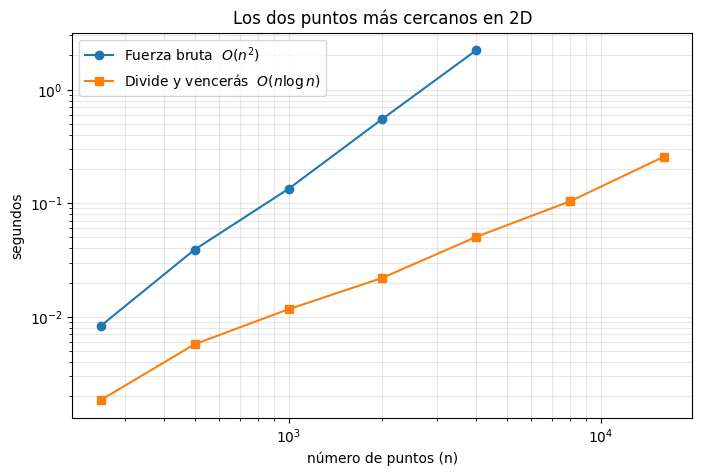

In [43]:
import matplotlib.pyplot as plt

random.seed(42)

TAMANOS_BRUTA = [250, 500, 1000, 2000, 4000]
TAMANOS_DYV = [250, 500, 1000, 2000, 4000, 8000, 16000]

tiempos_bruta, tiempos_dyv = [], []

print(f"{'n':>7} | {'fuerza bruta (s)':>17} | {'divide y vencerás (s)':>22} | {'mejora':>9}")
print("-" * 64)

for n in TAMANOS_DYV:
    puntos = nube(n, 2)

    _, t_dyv = cronometra(mas_cercanos_dyv, puntos)
    tiempos_dyv.append(t_dyv)

    if n in TAMANOS_BRUTA:
        _, t_bruta = cronometra(mas_cercanos_fuerza_bruta, puntos)
        tiempos_bruta.append(t_bruta)
        print(f"{n:>7,} | {t_bruta:>17.4f} | {t_dyv:>22.4f} | {t_bruta / t_dyv:>8.1f}x")
    else:
        print(f"{n:>7,} | {'(demasiado lenta)':>17} | {t_dyv:>22.4f} | {'-':>9}")

plt.figure(figsize=(8, 5))
plt.loglog(TAMANOS_BRUTA, tiempos_bruta, "o-", label="Fuerza bruta  $O(n^2)$")
plt.loglog(TAMANOS_DYV, tiempos_dyv, "s-", label="Divide y vencerás  $O(n \\log n)$")
plt.xlabel("número de puntos (n)")
plt.ylabel("segundos")
plt.title("Los dos puntos más cercanos en 2D")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()

### Resumen del apartado 5

| Dimensión | Algoritmo | Complejidad |
|---|---|---|
| Cualquiera | Fuerza bruta | $O(n^2)$ |
| 1D | Ordenar y mirar adyacentes | $O(n \log n)$ |
| 1D | Divide y vencerás (franja de 2 puntos) | $O(n \log n)$ |
| 2D | Divide y vencerás (franja de 7 vecinos) | $O(n \log n)$ |
| 3D | Divide y vencerás (losa) | $O(n \log n)$ en la práctica; $O(n \log^2 n)$ garantizado con la variante recursiva de Bentley |

En la gráfica log-log, la pendiente de una recta es el exponente del coste: la fuerza bruta sube con
pendiente $\approx 2$ y divide y vencerás con pendiente $\approx 1$. Por eso la ventaja no es un
factor constante, sino que **crece con $n$**: al doblar el número de puntos, la fuerza bruta
cuadruplica su tiempo mientras que divide y vencerás apenas lo duplica.

Merece la pena señalar que en 1D el algoritmo de divide y vencerás **no mejora** a la simple
ordenación: ambos son $O(n \log n)$ y ordenar es mucho más corto de escribir. Su valor aquí es
didáctico es el peldaño para entender la versión 2D, donde ya no existe ningún atajo equivalente.

---
# 6. Conclusiones

| Técnica | Problema resuelto | Complejidad | Cuándo aplicarla |
|---|---|---|---|
| Divide y vencerás | Torres de Hanói | $O(2^n)$ | El problema se parte en subproblemas **independientes** |
| Divide y vencerás | Fibonacci (ingenuo) | $O(\varphi^n)$ | **Mal ejemplo**: los subproblemas se solapan |
| Voraz | Devolución de cambio | $O(m \log m)$ | Cuando la elección local óptima lleva a la global |
| Vuelta atrás | N reinas | $O(N!)$ con poda | Espacio de búsqueda enorme pero muy podable |
| Programación dinámica | Viaje por el río | $O(n^3)$ | Subproblemas **solapados** y subestructura óptima |
| Divide y vencerás | Dos puntos más cercanos | $O(n \log n)$ | Combinar cuesta poco gracias a una propiedad geométrica |

**Lo que enseña comparar las cinco técnicas:**

1. **Divide y vencerás solo compensa si los subproblemas son independientes.** Fibonacci y el viaje
   por el río son el mismo tipo de recursión, pero en el segundo los subproblemas se solapan; por
   eso uno pide memoización o tabla programación dinámica y el otro no.

2. **El voraz es el más rápido y el más frágil.** No solo puede dar una solución peor que la óptima
   (`[11, 5, 1]` con 15), es que puede **no encontrar ninguna** aun existiendo (`[5, 3]` con 6).
   Antes de usarlo hay que demostrar que el problema tiene la propiedad de la elección voraz.

3. **En vuelta atrás, la poda no cambia el orden de magnitud pero decide si el programa termina.**
   Pasar la comprobación de conflictos de $O(\text{etapa}^2)$ a $O(1)$ con tres conjuntos no mejora
   la cota $O(N!)$ y, sin embargo, es la diferencia entre resolver $N = 11$ en un segundo o en un
   minuto.

4. **La estructura de datos que se elige para reconstruir la solución es parte del algoritmo.**
   En el viaje por el río, guardar en `RUTA[i][j]` el *predecesor* de `j` en lugar de un nodo
   intermedio cualquiera convierte una reconstrucción recursiva confusa que además perdía el
   destino en un bucle de tres líneas.

5. **Toda optimización necesita un control independiente.** Cada apartado compara el algoritmo
   eficiente contra una fuerza bruta evidentemente correcta. Es lo que permite afirmar que las
   versiones rápidas son además correctas, y no solo rápidas.